# GPT-2 Compression & Benchmark Pipeline

End-to-end notebook that:
1. **Static-profiles** GPT-2, builds a graph-based compression plan, and applies plan-based mixed-precision quantization. Saves the quantized model.
2. **Dynamic-profiles** the quantized model with `torch.profiler` and surfaces the top 5 ops by `%CUDA time` and by `%FLOPs`.
3. **Prunes** four variants with SparseGPT and saves each:
   - original GPT-2 with `2:4` pattern
   - original GPT-2 with `unstructured` 60% sparsity
   - quantized GPT-2 with `2:4` pattern
   - quantized GPT-2 with `unstructured` 60% sparsity
4. **Benchmarks** all 6 models (original, plan-quantized, + 4 pruned) on:
   - WikiText-2 sliding-window perplexity
   - LAMBADA last-token accuracy (full ~5,153 test split)
   - throughput at `seq_len=1024` (GPT-2's max), `batch_size=10`

**Requirements**: CUDA GPU with ~12+ GB free (fp32 GPT-2 + activations at batch=10), `transformers`, `datasets`, `torch>=2.1`. Run cells top-to-bottom.

## Setup

In [49]:
import os
import sys
import gc
import time
import math
import copy
from pathlib import Path

import torch
import torch.nn as nn

# Make repo modules importable
REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, REPO_ROOT)

OUTPUT_DIR = os.path.join(REPO_ROOT, "profiling_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_DIR = os.path.join(REPO_ROOT, "model")
os.makedirs(MODEL_DIR, exist_ok=True)
os.environ["HF_HOME"] = MODEL_DIR

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Pick the GPT-2 size to run the whole pipeline against ──
# Options: "gpt2" (124M), "gpt2-medium" (355M), "gpt2-large" (774M).
# Every saved checkpoint name and benchmark label is derived from ARCH, so
# different sizes don't collide on disk.
ARCH = "gpt2"
ARCH_PREFIX = ARCH.replace("-", "_")  # filename-safe (e.g. "gpt2_medium")

print(f"device = {DEVICE}")
print(f"arch   = {ARCH}  (prefix = {ARCH_PREFIX})")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Free: {torch.cuda.mem_get_info()[0] / 1024**3:.1f} GB")

device = cuda
arch   = gpt2  (prefix = gpt2)
  GPU: NVIDIA A100 80GB PCIe
  Free: 75.2 GB


In [50]:
# Import APIs from the repo
from models import load_gpt2
from static_profiler import StaticProfiler
from graph_export import _export_model
from main import apply_quant_plan, _load_local_for_perplexity
from dynamic_profile import run_dynamic_profile
from sparsegpt import (
    load_wikitext_calibration,
    prune_gpt2_sparsegpt,
    save_sparsegpt_model,
)
from perplexity import evaluate_perplexity, print_perplexity_table

from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained(ARCH, cache_dir=MODEL_DIR)
print(f"imports OK — tokenizer for {ARCH} loaded")

imports OK — tokenizer for gpt2 loaded


## Stage 1 — Static Profiling + Plan-Based Quantization

Run graph analysis on a fresh GPT-2 to build the per-layer mixed-precision plan, then apply it. The compression plan assigns each layer to INT4 / INT8 / FP16 based on Pareto rank (sensitivity × FLOPs share). Output: `profiling_results/gpt_2_plan_quantized.pt`.

**Skip behavior**: if `gpt_2_plan_quantized.pt` already exists in `profiling_results/`, the static-profile + quantize cells are skipped and the existing checkpoint is reused. Delete the file to force a full re-run.

In [51]:
# ── 1.0 Skip guard: reuse the quantized checkpoint if it already exists ──
quantized_path = os.path.join(OUTPUT_DIR, f"{ARCH_PREFIX}_plan_quantized.pt")
SKIP_STAGE_1 = os.path.isfile(quantized_path)
if SKIP_STAGE_1:
    size_mb = os.path.getsize(quantized_path) / (1024 * 1024)
    print(f"Found existing quantized checkpoint → {quantized_path} ({size_mb:.1f} MB)")
    print("Skipping Stage 1 (static profile + quantize). Delete the file to force a re-run.")
else:
    print(f"No checkpoint at {quantized_path} — running full Stage 1 pipeline.")

No checkpoint at /home/ubuntu/model_profiler/profiling_results/gpt2_plan_quantized.pt — running full Stage 1 pipeline.


In [52]:
# ── 1a. Load fresh GPT-2 for profiling ──
if not SKIP_STAGE_1:
    model_for_profile, sample_input, forward_fn = load_gpt2(ARCH)
    model_for_profile.eval()

    static_profiler = StaticProfiler()
    static_profile = static_profiler.profile(model_for_profile, model_name=ARCH)
    print(static_profile.summary())
else:
    print("[1a] skipped — reusing existing quantized checkpoint.")

  Loading gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  ✓ gpt2 loaded (124,439,808 params)

  STATIC PROFILE: gpt2
  Total Parameters:     124,439,808
  Trainable Parameters: 124,439,808
  Model Size:           474.70 MB
  Depth (major blocks): 1
────────────────────────────────────────────────────────────
  Layer Type Distribution:
    conv                  count=  48  params=  85,017,600
    dropout               count=  37  params=           0
    norm                  count=  25  params=      38,400
    attention             count=  12  params=           0
    embedding             count=   2  params=  39,383,808
    linear                count=   1  params=  38,597,376



In [53]:
# ── 1b. Graph export + graph-based profiling (compression plan) ──
if not SKIP_STAGE_1:
    graph_result = _export_model(
        model_for_profile, sample_input, forward_fn,
        model_name=ARCH, model_family="llm",
        save_graph=False, output_dir=OUTPUT_DIR, full_export=False,
    )
    print(graph_result.summary())
    assert graph_result.success, "graph export failed — re-run with --full-export"

    graph_profile = static_profiler.profile_from_graph(
        model_for_profile, graph_result,
        model_name=ARCH, model_family="llm",
        target_context_lengths=[512, 1024, 2048, 4096, 8192],
    )
    print(graph_profile.summary())
    compression_plan = graph_profile.compression_plan
    assert compression_plan is not None, "no compression plan produced"
else:
    print("[1b] skipped.")


  GRAPH EXPORT: gpt2 (llm)
  Status:        SUCCESS
  Export time:   0.000 s
──────────────────────────────────────────────────────────────────────
  Graph Overview:
    Total nodes:   273
    Parameters:    124,439,808
    Buffers:       0
    Graph depth:   0
──────────────────────────────────────────────────────────────────────
  Node Types:
    parameter                          148
    call_module                        125
──────────────────────────────────────────────────────────────────────
  Top 20 Operators (by frequency):
    Conv1D                                                  48
    Dropout                                                 37
    LayerNorm                                               25
    NewGELUActivation                                       12
    Embedding                                                2
    Linear                                                   1

──────────────────────────────────────────────────────────────────────
  COMPRESS

In [54]:
# ── 1c. Apply the plan and save ──
if not SKIP_STAGE_1:
    quantized_path = apply_quant_plan(
        model_for_profile, ARCH, compression_plan,
        sample_input=sample_input, forward_fn=forward_fn,
        output_dir=OUTPUT_DIR,
    )
    print(f"\nQuantized model saved → {quantized_path}")

    # Free profiling model — pruning steps will reload from saved files
    del model_for_profile, graph_result, graph_profile, static_profile
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
else:
    print(f"[1c] skipped — quantized_path = {quantized_path}")


######################################################################
#  APPLYING QUANTIZATION PLAN: gpt2
#  Avg target bits: 8.0
######################################################################
  Verifying quantized model...
  Forward pass OK

  Per-Layer Quantization:
  Layer                                             From     To       Params Reason
  ───────────────────────────────────────────── ──────── ────── ──────────── ───────────────────────────────────
  transformer.h.0.attn.c_attn                   torch.float32 → INT8     1,769,472 compute-bound (AI=219.3): INT8 sufficient
  transformer.h.0.attn.c_proj                   torch.float32 → INT8       589,824 compute-bound (AI=219.3): INT8 sufficient
  transformer.h.0.mlp.c_fc                      torch.float32 → INT8     2,359,296 compute-bound (AI=219.3): INT8 sufficient
  transformer.h.0.mlp.c_proj                    torch.float32 → INT8     2,359,296 compute-bound (AI=219.4): INT8 sufficient
  transformer.h.1.attn.c

## Stage 2 — Dynamic Profile of the Quantized Model

Run `torch.profiler` on the saved plan-quantized model and print the top 5 ops by `%CUDA time` (cost on the device) and by `%FLOPs` (compute concentration). These two views often disagree — high-FLOPs ops aren't always the slowest, since memory-bound or non-fused ops can dominate latency.

In [55]:
# Reload the saved quantized model into a fresh GPT-2
quantized_model = _load_local_for_perplexity(quantized_path, ARCH)
quantized_model.eval()

# Use the same tokenized sample input
dynamic_input = tokenizer(
    "The quick brown fox jumps over the lazy dog",
    return_tensors="pt",
)["input_ids"]

dyn_result = run_dynamic_profile(
    quantized_model, dynamic_input,
    model_name=f"{ARCH} plan-quantized",
    forward_fn=lambda m, x: m(x, labels=x),
    device=DEVICE,
    num_warmup=3, num_runs=20,
    save_trace=False, output_dir=OUTPUT_DIR,
)

  Unwrapping checkpoint (other keys: ['quant_assignments', 'avg_bits', 'layer_counts', 'layer_params', 'estimated_size_mb'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected

################################################################################
#  DYNAMIC PROFILING: gpt2 plan-quantized
#  Device: cuda, Warmup: 3, Runs: 20
################################################################################
  Warming up (3 runs)...
  Profiling (20 runs)...

  DYNAMIC PROFILE: gpt2 plan-quantized
  Device:            cuda
  Profiling runs:    20
  Total CPU time:    204.805 ms
  Total CUDA time:   85.781 ms
  Peak memory:       3991.38 MB
  Total FLOPs:       44.515 GFLOPs
────────────────────────────────────────────────────────────────────────────────
  Op Type Summary (aggregated):
  Op Type                              Calls     CPU ms    CUDA ms    Mem MB
  ─────────────────────────────────── ────── ────────── ────────── ─────────
  aten::addmm                            960     31.096     17.561      0.00
  cudaLaunchKernel                      4040     20.177          ─      0.00
  aten::lay

In [56]:
# Top 5 ops by %CUDA time (or %CPU time on CPU) and by %FLOPs
ops = dyn_result.op_profiles
use_cuda = dyn_result.device == "cuda"
self_time = lambda op: op.self_cuda_time_us if use_cuda else op.self_cpu_time_us
time_label = "%CUDA time" if use_cuda else "%CPU time"

total_self_time = sum(self_time(op) for op in ops) or 1.0
total_flops = sum(op.flops for op in ops if op.flops) or 1.0

print(f"\n{'='*86}")
print(f"  Top 5 ops by {time_label}")
print(f"{'='*86}")
print(f"  {'Op':<40s} {'self us':>12s} {time_label:>12s} {'GFLOPs':>10s} {'%FLOPs':>8s}")
print(f"  {'-'*40} {'-'*12} {'-'*12} {'-'*10} {'-'*8}")
top_by_time = sorted(ops, key=lambda op: -self_time(op))[:5]
for op in top_by_time:
    pct_t = 100.0 * self_time(op) / total_self_time
    pct_f = 100.0 * (op.flops or 0) / total_flops
    gflops = (op.flops or 0) / 1e9
    print(f"  {op.name[:40]:<40s} {self_time(op):>12.0f} {pct_t:>11.2f}% {gflops:>10.3f} {pct_f:>7.2f}%")

print(f"\n{'='*86}")
print(f"  Top 5 ops by %FLOPs")
print(f"{'='*86}")
print(f"  {'Op':<40s} {'GFLOPs':>10s} {'%FLOPs':>8s} {'self us':>12s} {time_label:>12s}")
print(f"  {'-'*40} {'-'*10} {'-'*8} {'-'*12} {'-'*12}")
top_by_flops = sorted([op for op in ops if op.flops], key=lambda op: -op.flops)[:5]
for op in top_by_flops:
    pct_t = 100.0 * self_time(op) / total_self_time
    pct_f = 100.0 * op.flops / total_flops
    gflops = op.flops / 1e9
    print(f"  {op.name[:40]:<40s} {gflops:>10.3f} {pct_f:>7.2f}% {self_time(op):>12.0f} {pct_t:>11.2f}%")

del quantized_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()


  Top 5 ops by %CUDA time
  Op                                            self us   %CUDA time     GFLOPs   %FLOPs
  ---------------------------------------- ------------ ------------ ---------- --------
  aten::addmm                                     17561       25.41%     30.576   68.69%
  void cutlass::Kernel2<cutlass_80_simt_sg        10484       15.17%      0.000    0.00%
  ampere_sgemm_64x32_sliced1x4_nn                  4015        5.81%      0.000    0.00%
  aten::mm                                         3499        5.06%     13.895   31.21%
  ampere_sgemm_128x32_tn                           3295        4.77%      0.000    0.00%

  Top 5 ops by %FLOPs
  Op                                           GFLOPs   %FLOPs      self us   %CUDA time
  ---------------------------------------- ---------- -------- ------------ ------------
  aten::addmm                                  30.576   68.69%        17561       25.41%
  aten::mm                                     13.895   31.2

## Stage 3 — SparseGPT Pruning (4 variants)

Each variant calibrates with WikiText-2 train (32 sequences × 1024 tokens — paper recipe is 128, 32 is sufficient for a sanity-check pass and 4× faster). Outputs:
- `gpt_2_sparsegpt_2_4.pt`        — original GPT-2, 2:4 (cuSPARSELt-ready, fp16)
- `gpt_2_sparsegpt_unstr60.pt`    — original GPT-2, unstructured 60%
- `gpt_2_q_sparsegpt_2_4.pt`      — quantized GPT-2, 2:4
- `gpt_2_q_sparsegpt_unstr60.pt`  — quantized GPT-2, unstructured 60%

In [57]:
# Calibration data (shared across the pruning runs that still need to run).
# All four pruned checkpoints are produced by Stage 3; if every one of them
# is already on disk we don't need to download/tokenize WikiText-2 again.
PRUNE_SAMPLES = 32
PRUNE_SEQLEN = 1024

PRUNE_TARGETS = [
    # (filename, src_label, pattern, sparsity, get_model_factory_name)
    (f"{ARCH_PREFIX}_sparsegpt_2_4.pt",        ARCH,                "2:4",          0.5, "_fresh_original_gpt2"),
    (f"{ARCH_PREFIX}_sparsegpt_unstr60.pt",    ARCH,                "unstructured", 0.6, "_fresh_original_gpt2"),
    (f"{ARCH_PREFIX}_q_sparsegpt_2_4.pt",      f"{ARCH}-quantized", "2:4",          0.5, "_fresh_quantized_gpt2"),
    (f"{ARCH_PREFIX}_q_sparsegpt_unstr60.pt",  f"{ARCH}-quantized", "unstructured", 0.6, "_fresh_quantized_gpt2"),
]
_existing = [n for n, *_ in PRUNE_TARGETS
             if os.path.isfile(os.path.join(OUTPUT_DIR, n))]
ALL_PRUNED_EXIST = len(_existing) == len(PRUNE_TARGETS)

print(f"Pruned checkpoints already present: {len(_existing)}/{len(PRUNE_TARGETS)}")
for n in _existing:
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, n)) / (1024 * 1024)
    print(f"  ✓ {n} ({size_mb:.1f} MB)")

if ALL_PRUNED_EXIST:
    print("All four pruned checkpoints exist — skipping WikiText-2 calibration load.")
    calib = None
else:
    calib = load_wikitext_calibration(
        tokenizer, n_samples=PRUNE_SAMPLES, seqlen=PRUNE_SEQLEN,
    )
    print(f"calibration: {calib.shape}")

Pruned checkpoints already present: 0/4


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2428601 > 1024). Running this sequence through the model will result in indexing errors


calibration: torch.Size([32, 1024])


In [58]:
def _fresh_original_gpt2():
    """A clean GPT-2 each call — pruning mutates weights in place."""
    return GPT2LMHeadModel.from_pretrained(ARCH, cache_dir=MODEL_DIR).eval()

def _fresh_quantized_gpt2():
    """Reload the saved plan-quantized model into a clean architecture."""
    return _load_local_for_perplexity(quantized_path, ARCH)

def prune_and_save(get_model, src_label, pattern, sparsity, save_name):
    """Run SparseGPT on a freshly-loaded model and save it. Skip if the
    target file already exists — pruning is the slowest step in the pipeline.
    """
    save_path = os.path.join(OUTPUT_DIR, save_name)
    if os.path.isfile(save_path):
        size_mb = os.path.getsize(save_path) / (1024 * 1024)
        print(f"[skip] {save_name} already exists ({size_mb:.1f} MB)")
        return save_path

    print(f"\n{'#'*78}\n#  PRUNE: {src_label} | pattern={pattern} | sparsity={sparsity}\n{'#'*78}")
    model = get_model()
    convert = (pattern == "2:4" and DEVICE == "cuda")
    result = prune_gpt2_sparsegpt(
        model, calib, pattern=pattern, sparsity=sparsity,
        device=DEVICE, convert_to_sparse=convert,
        sparse_dtype=torch.float16,
    )
    save_sparsegpt_model(
        model, src_label, result,
        save_path=save_path, output_dir=OUTPUT_DIR,
        sparse_dtype=torch.float16 if convert else None,
    )
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return save_path

In [59]:
# 3a. Original GPT-2 → SparseGPT 2:4
path_orig_24 = prune_and_save(
    _fresh_original_gpt2, ARCH, "2:4", 0.5,
    f"{ARCH_PREFIX}_sparsegpt_2_4.pt",
)


##############################################################################
#  PRUNE: gpt2 | pattern=2:4 | sparsity=0.5
##############################################################################


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  [sparsegpt] Capturing block-0 inputs: 32×1024 tokens, n_embd=768...
  [sparsegpt] Block 1/12...
    transformer.h.0.attn.c_attn: sparsity=50.00%, loss=63.9741
    transformer.h.0.attn.c_proj: sparsity=50.00%, loss=8.5447
    transformer.h.0.mlp.c_fc: sparsity=50.00%, loss=41.9195
    transformer.h.0.mlp.c_proj: sparsity=50.00%, loss=17.9470
  [sparsegpt] Block 2/12...
    transformer.h.1.attn.c_attn: sparsity=50.00%, loss=27.8832
    transformer.h.1.attn.c_proj: sparsity=50.00%, loss=5.2993
    transformer.h.1.mlp.c_fc: sparsity=50.00%, loss=41.0376
    transformer.h.1.mlp.c_proj: sparsity=50.00%, loss=11.2097
  [sparsegpt] Block 3/12...
    transformer.h.2.attn.c_attn: sparsity=50.00%, loss=46.9961
    transformer.h.2.attn.c_proj: sparsity=50.00%, loss=5.5297
    transformer.h.2.mlp.c_fc: sparsity=50.00%, loss=77.7252
    transformer.h.2.mlp.c_proj: sparsity=50.00%, loss=15.3355
  [sparsegpt] Block 4/12...
    transformer.h.3.attn.c_attn: sparsity=50.00%, loss=80.0456
    transforme

In [60]:
# 3b. Original GPT-2 → SparseGPT unstructured 60%
path_orig_unstr = prune_and_save(
    _fresh_original_gpt2, ARCH, "unstructured", 0.6,
    f"{ARCH_PREFIX}_sparsegpt_unstr60.pt",
)


##############################################################################
#  PRUNE: gpt2 | pattern=unstructured | sparsity=0.6
##############################################################################


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  [sparsegpt] Capturing block-0 inputs: 32×1024 tokens, n_embd=768...
  [sparsegpt] Block 1/12...
    transformer.h.0.attn.c_attn: sparsity=60.00%, loss=28.9000
    transformer.h.0.attn.c_proj: sparsity=60.00%, loss=0.4506
    transformer.h.0.mlp.c_fc: sparsity=60.00%, loss=35.0610
    transformer.h.0.mlp.c_proj: sparsity=60.00%, loss=16.4101
  [sparsegpt] Block 2/12...
    transformer.h.1.attn.c_attn: sparsity=60.00%, loss=15.5463
    transformer.h.1.attn.c_proj: sparsity=60.00%, loss=2.8930
    transformer.h.1.mlp.c_fc: sparsity=60.00%, loss=31.9451
    transformer.h.1.mlp.c_proj: sparsity=60.00%, loss=8.2697
  [sparsegpt] Block 3/12...
    transformer.h.2.attn.c_attn: sparsity=60.00%, loss=30.9088
    transformer.h.2.attn.c_proj: sparsity=60.00%, loss=4.7755
    transformer.h.2.mlp.c_fc: sparsity=60.00%, loss=65.9364
    transformer.h.2.mlp.c_proj: sparsity=60.00%, loss=12.3641
  [sparsegpt] Block 4/12...
    transformer.h.3.attn.c_attn: sparsity=60.00%, loss=67.3908
    transformer

In [61]:
# 3c. Quantized GPT-2 → SparseGPT 2:4
path_q_24 = prune_and_save(
    _fresh_quantized_gpt2, f"{ARCH}-quantized", "2:4", 0.5,
    f"{ARCH_PREFIX}_q_sparsegpt_2_4.pt",
)


##############################################################################
#  PRUNE: gpt2-quantized | pattern=2:4 | sparsity=0.5
##############################################################################
  Unwrapping checkpoint (other keys: ['quant_assignments', 'avg_bits', 'layer_counts', 'layer_params', 'estimated_size_mb'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected
  [sparsegpt] Capturing block-0 inputs: 32×1024 tokens, n_embd=768...
  [sparsegpt] Block 1/12...
    transformer.h.0.attn.c_attn: sparsity=50.00%, loss=64.2031
    transformer.h.0.attn.c_proj: sparsity=50.20%, loss=8.6872
    transformer.h.0.mlp.c_fc: sparsity=50.00%, loss=42.5672
    transformer.h.0.mlp.c_proj: sparsity=50.04%, loss=18.6549
  [sparsegpt] Block 2/12...
    transformer.h.1.attn.c_attn: sparsity=50.00%, loss=28.2539
    transformer.h.1.attn.c_proj: sparsity=50.16%, loss=5.7108
    transformer.h.1.mlp.c_fc: sparsity=50.00%, loss=39.9988
    transformer.h.1.mlp.c_proj: sparsity=51.15%, loss=11.0986
  [sparsegpt] Block 3/12...
    transformer.h.2.attn.c_attn: sparsity=50.00%, loss=47.2005
    transformer.h.2.attn.c_proj: sparsity=50.08%, loss=5.1974
    transformer.h.2.mlp.c_fc: sparsity=50.02%, loss=79.0135
    transformer.h.2.mlp.c_proj: sparsity=50.34%, loss=15.4766
  [sparsegpt] Block 4/12...
    transformer.h.3.a

In [62]:
# 3d. Quantized GPT-2 → SparseGPT unstructured 60%
path_q_unstr = prune_and_save(
    _fresh_quantized_gpt2, f"{ARCH}-quantized", "unstructured", 0.6,
    f"{ARCH_PREFIX}_q_sparsegpt_unstr60.pt",
)


##############################################################################
#  PRUNE: gpt2-quantized | pattern=unstructured | sparsity=0.6
##############################################################################
  Unwrapping checkpoint (other keys: ['quant_assignments', 'avg_bits', 'layer_counts', 'layer_params', 'estimated_size_mb'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected
  [sparsegpt] Capturing block-0 inputs: 32×1024 tokens, n_embd=768...
  [sparsegpt] Block 1/12...
    transformer.h.0.attn.c_attn: sparsity=60.01%, loss=29.2041
    transformer.h.0.attn.c_proj: sparsity=60.00%, loss=0.5399
    transformer.h.0.mlp.c_fc: sparsity=60.01%, loss=35.7752
    transformer.h.0.mlp.c_proj: sparsity=60.00%, loss=17.2020
  [sparsegpt] Block 2/12...
    transformer.h.1.attn.c_attn: sparsity=60.00%, loss=15.7815
    transformer.h.1.attn.c_proj: sparsity=60.01%, loss=3.0259
    transformer.h.1.mlp.c_fc: sparsity=60.00%, loss=30.5484
    transformer.h.1.mlp.c_proj: sparsity=60.01%, loss=5.6736
  [sparsegpt] Block 3/12...
    transformer.h.2.attn.c_attn: sparsity=60.01%, loss=30.7877
    transformer.h.2.attn.c_proj: sparsity=60.01%, loss=4.5505
    transformer.h.2.mlp.c_fc: sparsity=60.04%, loss=67.7748
    transformer.h.2.mlp.c_proj: sparsity=60.00%, loss=7.0007
  [sparsegpt] Block 4/12...
    transformer.h.3.att

In [63]:
# ── Size comparison: FP32 base vs plan-quant vs the 4 pruned variants ──
def _file_size_mb(p):
    return os.path.getsize(p) / (1024 * 1024) if os.path.isfile(p) else None

# Compute the FP32 baseline size from a freshly-instantiated model (no save).
_base_model = GPT2LMHeadModel.from_pretrained(ARCH, cache_dir=MODEL_DIR)
fp32_bytes = sum(p.numel() * p.element_size() for p in _base_model.parameters())
fp32_bytes += sum(b.numel() * b.element_size() for b in _base_model.buffers())
fp32_size_mb = fp32_bytes / (1024 * 1024)
fp32_params = sum(p.numel() for p in _base_model.parameters())
del _base_model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

rows = [(f"{ARCH} (FP32 base)",                  None,            fp32_size_mb,                "fp32 reference")]
rows.append((f"{ARCH} plan-quant",               quantized_path,  _file_size_mb(quantized_path), "INT4/INT8/FP16 mix"))
rows.append((f"{ARCH} + SparseGPT 2:4",          path_orig_24,    _file_size_mb(path_orig_24),   "fp16, 50% 2:4"))
rows.append((f"{ARCH} + SparseGPT unstr60",      path_orig_unstr, _file_size_mb(path_orig_unstr),"fp32, 60% unstructured"))
rows.append((f"{ARCH}-quant + SparseGPT 2:4",    path_q_24,       _file_size_mb(path_q_24),      "quant + fp16, 50% 2:4"))
rows.append((f"{ARCH}-quant + SparseGPT unstr60",path_q_unstr,    _file_size_mb(path_q_unstr),   "quant + 60% unstructured"))

print("=" * 110)
print(f"  CHECKPOINT SIZE COMPARISON  |  baseline: {ARCH} FP32 ({fp32_params:,} params, {fp32_size_mb:.1f} MB)")
print("=" * 110)
print(f"  {'Model':<38s} {'Size MB':>10s} {'vs FP32':>10s} {'On disk?':>10s}  Notes")
print(f"  {'-'*38} {'-'*10} {'-'*10} {'-'*10}  {'-'*40}")
for label, fpath, size_mb, notes in rows:
    if size_mb is None:
        print(f"  {label[:38]:<38s} {'—':>10s} {'—':>10s} {'MISSING':>10s}  {notes}")
        continue
    ratio = size_mb / fp32_size_mb
    on_disk = "yes" if fpath else "in-mem"
    print(f"  {label[:38]:<38s} {size_mb:>10.1f} {ratio:>9.1%} {on_disk:>10s}  {notes}")
print("=" * 110)
print("  Note: SparseGPT 2:4 stores fp16 dense weights with zeros preserved (not")
print("  bit-packed), so the on-disk file is ~50% of fp32 base, not 25%. The")
print("  cuSPARSELt path packs to ~25% effective at runtime via SparseSemiStructuredTensor.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  CHECKPOINT SIZE COMPARISON  |  baseline: gpt2 FP32 (124,439,808 params, 474.7 MB)
  Model                                     Size MB    vs FP32   On disk?  Notes
  -------------------------------------- ---------- ---------- ----------  ----------------------------------------
  gpt2 (FP32 base)                            474.7    100.0%     in-mem  fp32 reference
  gpt2 plan-quant                             474.8    100.0%        yes  INT4/INT8/FP16 mix
  gpt2 + SparseGPT 2:4                        311.0     65.5%        yes  fp16, 50% 2:4
  gpt2 + SparseGPT unstr60                    622.0    131.0%        yes  fp32, 60% unstructured
  gpt2-quant + SparseGPT 2:4                  311.0     65.5%        yes  quant + fp16, 50% 2:4
  gpt2-quant + SparseGPT unstr60              622.0    131.0%        yes  quant + 60% unstructured
  Note: SparseGPT 2:4 stores fp16 dense weights with zeros preserved (not
  bit-packed), so the on-disk file is ~50% of fp32 base, not 25%. The
  cuSPARSELt 

## Stage 4 — Benchmarks

All 6 models are evaluated:
1. `GPT-2 (FP32 base)` — fresh from HuggingFace
2. `GPT-2 plan-quant` — Stage 1 output
3. `GPT-2 + SparseGPT 2:4`
4. `GPT-2 + SparseGPT unstr60`
5. `GPT-2-quant + SparseGPT 2:4`
6. `GPT-2-quant + SparseGPT unstr60`

Each model is loaded → measured → freed before the next, so peak memory stays at one model. Three metrics are collected per model and merged into one table at the end.

In [64]:
# Registry of models to benchmark
BENCH_MODELS = [
    (f"{ARCH} (FP32 base)",                  None,             "baseline"),
    (f"{ARCH} plan-quant",                   quantized_path,   "plan-quant"),
    (f"{ARCH} + SparseGPT 2:4",              path_orig_24,     "sparsegpt 2:4"),
    (f"{ARCH} + SparseGPT unstr60",          path_orig_unstr,  "sparsegpt unstructured 60%"),
    (f"{ARCH}-quant + SparseGPT 2:4",        path_q_24,        "plan-quant + sparsegpt 2:4"),
    (f"{ARCH}-quant + SparseGPT unstr60",    path_q_unstr,     "plan-quant + sparsegpt unstructured 60%"),
]

def _load_bench_model(label, path):
    """FP32 base when path is None; otherwise reload the saved checkpoint."""
    if path is None:
        m = GPT2LMHeadModel.from_pretrained(ARCH, cache_dir=MODEL_DIR)
    else:
        m = _load_local_for_perplexity(path, ARCH)
    m.eval()
    return m

### 4a. WikiText-2 perplexity

In [65]:
ppl_results = {}
for label, path, notes in BENCH_MODELS:
    print(f"\n[ppl] {label}")
    model = _load_bench_model(label, path)
    res = evaluate_perplexity(
        model, tokenizer, label=label, device=DEVICE,
        max_length=1024, stride=512, max_tokens=None, notes=notes,
    )
    ppl_results[label] = res
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print_perplexity_table(list(ppl_results.values()))


[ppl] gpt2 (FP32 base)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  [perplexity:gpt2 (FP32 base)] eval tokens=287,644, window=1024, stride=512, device=cuda
    window 10: pos=5,632/287,644, running ppl=27.452
    window 20: pos=10,752/287,644, running ppl=27.850
    window 30: pos=15,872/287,644, running ppl=25.728
    window 40: pos=20,992/287,644, running ppl=26.376
    window 50: pos=26,112/287,644, running ppl=26.111
    window 60: pos=31,232/287,644, running ppl=26.459
    window 70: pos=36,352/287,644, running ppl=26.583
    window 80: pos=41,472/287,644, running ppl=26.464
    window 90: pos=46,592/287,644, running ppl=26.896
    window 100: pos=51,712/287,644, running ppl=27.323
    window 110: pos=56,832/287,644, running ppl=27.520
    window 120: pos=61,952/287,644, running ppl=26.805
    window 130: pos=67,072/287,644, running ppl=26.050
    window 140: pos=72,192/287,644, running ppl=25.856
    window 150: pos=77,312/287,644, running ppl=24.875
    window 160: pos=82,432/287,644, running ppl=24.488
    window 170: pos=87,552/287,644, runn

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected
  [perplexity:gpt2 plan-quant] eval tokens=287,644, window=1024, stride=512, device=cuda
    window 10: pos=5,632/287,644, running ppl=31.779
    window 20: pos=10,752/287,644, running ppl=32.140
    window 30: pos=15,872/287,644, running ppl=29.613
    window 40: pos=20,992/287,644, running ppl=30.279
    window 50: pos=26,112/287,644, running ppl=29.846
    window 60: pos=31,232/287,644, running ppl=30.245
    window 70: pos=36,352/287,644, running ppl=30.452
    window 80: pos=41,472/287,644, running ppl=30.332
    window 90: pos=46,592/287,644, running ppl=30.941
    window 100: pos=51,712/287,644, running ppl=31.498
    window 110: pos=56,832/287,644, running ppl=31.783
    window 120: pos=61,952/287,644, running ppl=30.955
    window 130: pos=67,072/287,644, running ppl=30.039
    window 140: pos=72,192/287,644, running ppl=29.794
    window 150: pos=77,312/287,644, running ppl=28.639
    window 160: pos=82,432/287,644, runn

...

  Loaded weights (strict)
  [perplexity:gpt2 + SparseGPT unstr60] eval tokens=287,644, window=1024, stride=512, device=cuda
    window 10: pos=5,632/287,644, running ppl=73.463
    window 20: pos=10,752/287,644, running ppl=75.098
    window 30: pos=15,872/287,644, running ppl=66.613
    window 40: pos=20,992/287,644, running ppl=69.057
    window 50: pos=26,112/287,644, running ppl=67.087
    window 60: pos=31,232/287,644, running ppl=67.213
    window 70: pos=36,352/287,644, running ppl=67.304
    window 80: pos=41,472/287,644, running ppl=67.234
    window 90: pos=46,592/287,644, running ppl=69.285
    window 100: pos=51,712/287,644, running ppl=70.762
    window 110: pos=56,832/287,644, running ppl=72.132
    window 120: pos=61,952/287,644, running ppl=70.458
    window 130: pos=67,072/287,644, running ppl=68.518
    window 140: pos=72,192/287,644, running ppl=67.996
    window 150: pos=77,312/287,644, running ppl=65.700
    window 160: pos=82,432/287,644, running ppl=65.035
    wi

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Restored HF Conv1D layout for 48 weight(s) (transposed from nn.Linear shape — saved by 2:4 prune flow)
  Loaded weights (strict)
  [perplexity:gpt2-quant + SparseGPT 2:4] eval tokens=287,644, window=1024, stride=512, device=cuda
    window 10: pos=5,632/287,644, running ppl=67.284
    window 20: pos=10,752/287,644, running ppl=68.448
    window 30: pos=15,872/287,644, running ppl=62.152
    window 40: pos=20,992/287,644, running ppl=63.447
    window 50: pos=26,112/287,644, running ppl=61.769
    window 60: pos=31,232/287,644, running ppl=62.010
    window 70: pos=36,352/287,644, running ppl=62.466
    window 80: pos=41,472/287,644, running ppl=62.413
    window 90: pos=46,592/287,644, running ppl=64.581
    window 100: pos=51,712/287,644, running ppl=65.976
    window 110: pos=56,832/287,644, running ppl=67.759
    window 120: pos=61,952/287,644, running ppl=66.395
    window 130: pos=67,072/287,644, running ppl=65.053
    window 140: pos=72,192/287,644, running ppl=64.647
    windo

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (strict)
  [perplexity:gpt2-quant + SparseGPT unstr60] eval tokens=287,644, window=1024, stride=512, device=cuda
    window 10: pos=5,632/287,644, running ppl=121.276
    window 20: pos=10,752/287,644, running ppl=126.482
    window 30: pos=15,872/287,644, running ppl=107.778
    window 40: pos=20,992/287,644, running ppl=110.886
    window 50: pos=26,112/287,644, running ppl=106.846
    window 60: pos=31,232/287,644, running ppl=107.821
    window 70: pos=36,352/287,644, running ppl=108.815
    window 80: pos=41,472/287,644, running ppl=109.172
    window 90: pos=46,592/287,644, running ppl=113.179
    window 100: pos=51,712/287,644, running ppl=115.637
    window 110: pos=56,832/287,644, running ppl=118.501
    window 120: pos=61,952/287,644, running ppl=116.572
    window 130: pos=67,072/287,644, running ppl=114.603
    window 140: pos=72,192/287,644, running ppl=113.812
    window 150: pos=77,312/287,644, running ppl=110.050
    window 160: pos=82,432/287,644, runn

### 4b. LAMBADA accuracy (last-token match)

Tokenize the full LAMBADA sentence, predict the last token from the prefix, and check whether the greedy argmax matches the actual last token. This is the standard fast variant of LAMBADA used to compare GPT-2-style models. (The original LAMBADA metric requires the entire last *word* to be correctly generated; for multi-token last words, last-token-match is a slight overestimate but ranks models the same way.)

In [66]:
from datasets import load_dataset

def _load_lambada():
    """Try the canonical LAMBADA dataset names; HF has a few mirrors."""
    last_err = None
    for name in ("EleutherAI/lambada_openai", "craffel/openai_lambada", "lambada"):
        try:
            ds = load_dataset(name, split="test")
            print(f"  loaded LAMBADA from '{name}' — {len(ds)} examples")
            return ds
        except Exception as e:
            last_err = e
    raise RuntimeError(f"could not load any LAMBADA mirror: {last_err}")

lambada_ds = _load_lambada()
# Pre-tokenize once (token IDs only depend on tokenizer, not model)
_lambada_tokens = []
for ex in lambada_ds:
    text = ex.get("text") or ex.get("sentence") or ""
    if not text:
        continue
    ids = tokenizer(text, return_tensors="pt").input_ids[0]
    if ids.numel() < 2:
        continue
    _lambada_tokens.append(ids)
print(f"  pre-tokenized {len(_lambada_tokens):,} examples")

  loaded LAMBADA from 'EleutherAI/lambada_openai' — 5153 examples
  pre-tokenized 5,153 examples


In [67]:
def evaluate_lambada(model, device, examples, max_ctx=1024, log_every=500):
    """Last-token-match accuracy on pre-tokenized LAMBADA.

    For each example, feed tokens[:-1] and check if argmax of the final-position
    logit equals tokens[-1]. Long examples (>1024) are left-truncated to keep
    the most recent context.
    """
    model.eval()
    try:
        model.to(device)
    except Exception:
        pass
    n_correct = 0
    n_total = 0
    t0 = time.time()
    with torch.no_grad():
        for i, ids in enumerate(examples):
            if ids.numel() > max_ctx:
                ids = ids[-max_ctx:]
            target = int(ids[-1].item())
            prefix = ids[:-1].unsqueeze(0).to(device)
            logits = model(prefix).logits[0, -1, :]
            pred = int(torch.argmax(logits).item())
            n_correct += int(pred == target)
            n_total += 1
            if log_every and (i + 1) % log_every == 0:
                acc = n_correct / n_total
                print(f"    {i+1}/{len(examples)}: running acc={acc:.4f}")
    elapsed = time.time() - t0
    acc = n_correct / max(n_total, 1)
    return acc, n_total, elapsed

In [68]:
lambada_results = {}
for label, path, notes in BENCH_MODELS:
    print(f"\n[lambada] {label}")
    model = _load_bench_model(label, path)
    acc, n, secs = evaluate_lambada(model, DEVICE, _lambada_tokens)
    print(f"  acc={acc:.4f} ({n} examples, {secs:.1f}s)")
    lambada_results[label] = {"accuracy": acc, "n": n, "seconds": secs}
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


[lambada] gpt2 (FP32 base)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

    500/5153: running acc=0.4760
    1000/5153: running acc=0.4660
    1500/5153: running acc=0.4647
    2000/5153: running acc=0.4700
    2500/5153: running acc=0.4724
    3000/5153: running acc=0.4687
    3500/5153: running acc=0.4654
    4000/5153: running acc=0.4685
    4500/5153: running acc=0.4673
    5000/5153: running acc=0.4672
  acc=0.4667 (5153 examples, 29.9s)

[lambada] gpt2 plan-quant
  Unwrapping checkpoint (other keys: ['quant_assignments', 'avg_bits', 'layer_counts', 'layer_params', 'estimated_size_mb'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected
    500/5153: running acc=0.4300
    1000/5153: running acc=0.4230
    1500/5153: running acc=0.4220
    2000/5153: running acc=0.4255
    2500/5153: running acc=0.4236
    3000/5153: running acc=0.4180
    3500/5153: running acc=0.4160
    4000/5153: running acc=0.4180
    4500/5153: running acc=0.4171
    5000/5153: running acc=0.4162
  acc=0.4168 (5153 examples, 29.6s)

[lambada] gpt2 + SparseGPT 2:4
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


...

  Loaded weights (strict)
    500/5153: running acc=0.2660
    1000/5153: running acc=0.2690
    1500/5153: running acc=0.2720
    2000/5153: running acc=0.2775
    2500/5153: running acc=0.2704
    3000/5153: running acc=0.2710
    3500/5153: running acc=0.2723
    4000/5153: running acc=0.2720
    4500/5153: running acc=0.2740
    5000/5153: running acc=0.2732
  acc=0.2729 (5153 examples, 29.7s)

[lambada] gpt2-quant + SparseGPT 2:4
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Restored HF Conv1D layout for 48 weight(s) (transposed from nn.Linear shape — saved by 2:4 prune flow)
  Loaded weights (strict)
    500/5153: running acc=0.3120
    1000/5153: running acc=0.2950
    1500/5153: running acc=0.2933
    2000/5153: running acc=0.2970
    2500/5153: running acc=0.2928
    3000/5153: running acc=0.2910
    3500/5153: running acc=0.2943
    4000/5153: running acc=0.2940
    4500/5153: running acc=0.2944
    5000/5153: running acc=0.2928
  acc=0.2919 (5153 examples, 29.5s)

[lambada] gpt2-quant + SparseGPT unstr60
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (strict)
    500/5153: running acc=0.2280
    1000/5153: running acc=0.2190
    1500/5153: running acc=0.2220
    2000/5153: running acc=0.2245
    2500/5153: running acc=0.2216
    3000/5153: running acc=0.2173
    3500/5153: running acc=0.2186
    4000/5153: running acc=0.2203
    4500/5153: running acc=0.2207
    5000/5153: running acc=0.2190
  acc=0.2185 (5153 examples, 29.8s)


### 4c. Throughput at seq_len=1024, batch_size=10

GPT-2's `n_positions=1024`, so we measure at the model's max context. Throughput is reported as **tokens/sec**: `(batch × seq_len) / time_per_forward`. Run 3 warmup iterations + 10 timed iterations, with `cuda.synchronize()` around each pass.

**2:4 cuSPARSELt rewrap.** The pruning save flow materializes `SparseSemiStructuredTensor` weights back to dense fp16 for portable `.pt` loading, which means a vanilla reload runs through dense GEMM — no sparse-tensor-core acceleration. For 2:4 checkpoints we re-wrap each `nn.Linear` weight via `torch.sparse.to_sparse_semi_structured(...)` after load, which routes the matmul through cuSPARSELt on Ampere+. Expect the 2:4 rows to win from a *combination* of fp16 GEMM (vs FP32 base) + sparse tensor cores; the unstructured-60% rows have no analogous fast path on stock PyTorch and will track the dense baseline.

In [69]:
BATCH = 10
SEQ_LEN = 1024
WARMUP = 3
RUNS = 10


def _rewrap_24_for_inference(model, dtype=torch.float16,
                              skip_substrings=("lm_head", "wte", "wpe")):
    """Cast `model` to `dtype` on cuda and re-wrap each eligible nn.Linear
    weight as a SparseSemiStructuredTensor so the matmul dispatches to
    cuSPARSELt's 2:4 path. No-op on CPU.

    Returns the number of layers wrapped. Layers with K not divisible by
    16 (fp16/bf16) or 32 (int8) are skipped — cuSPARSELt requires those.
    """
    if not torch.cuda.is_available():
        print("    [rewrap] CUDA not available — leaving model dense.")
        return 0
    try:
        from torch.sparse import to_sparse_semi_structured
    except ImportError:
        print("    [rewrap] torch.sparse.to_sparse_semi_structured unavailable.")
        return 0

    model.to(dtype=dtype).cuda()
    n_wrapped = 0
    n_skipped_k = 0
    min_k = 32 if dtype == torch.int8 else 16
    for name, mod in model.named_modules():
        if not isinstance(mod, nn.Linear):
            continue
        if any(s in name for s in skip_substrings):
            continue
        if mod.weight.shape[1] % min_k != 0:
            n_skipped_k += 1
            continue
        try:
            sparse = to_sparse_semi_structured(
                mod.weight.data.contiguous().to(device="cuda", dtype=dtype)
            )
            mod.weight = nn.Parameter(sparse, requires_grad=False)
            if getattr(mod, "bias", None) is not None:
                mod.bias.data = mod.bias.data.to(device="cuda", dtype=dtype)
            n_wrapped += 1
        except Exception as e:
            # Layer didn't actually have 2:4 sparsity in the right pattern
            # (would only happen on a non-2:4 file mistakenly fed in here).
            print(f"    [rewrap] {name}: {type(e).__name__}: {e}")
    if n_skipped_k:
        print(f"    [rewrap] skipped {n_skipped_k} layers (K not divisible by {min_k})")
    return n_wrapped


def evaluate_throughput(model, device, batch=BATCH, seq_len=SEQ_LEN,
                        warmup=WARMUP, runs=RUNS):
    model.eval()
    try:
        model.to(device)
    except Exception:
        pass
    inp = torch.randint(0, 50257, (batch, seq_len), dtype=torch.long, device=device)
    with torch.no_grad():
        for _ in range(warmup):
            model(inp)
    if device == "cuda":
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(runs):
            t0 = time.perf_counter()
            model(inp)
            if device == "cuda":
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    mean_s = sum(times) / len(times)
    tokens = batch * seq_len
    return {
        "mean_latency_s": mean_s,
        "min_latency_s": min(times),
        "tokens_per_sec": tokens / mean_s,
        "batch": batch,
        "seq_len": seq_len,
        "runs": runs,
    }

In [70]:
throughput_results = {}
for label, path, notes in BENCH_MODELS:
    print(f"\n[throughput] {label}")
    model = _load_bench_model(label, path)

    # 2:4 checkpoints: re-wrap as SparseSemiStructuredTensor for cuSPARSELt
    # dispatch. Detected by filename suffix '_2_4'. Other variants stay dense.
    is_24 = path is not None and "_2_4" in os.path.basename(path)
    if is_24:
        n_wrapped = _rewrap_24_for_inference(model, dtype=torch.float16)
        print(f"  re-wrapped {n_wrapped} Linear layers as 2:4 SparseSemiStructuredTensor (fp16)")

    try:
        r = evaluate_throughput(model, DEVICE)
        print(f"  {r['tokens_per_sec']:>10,.1f} tok/s  |  mean={r['mean_latency_s']*1000:.2f} ms  |  min={r['min_latency_s']*1000:.2f} ms")
        throughput_results[label] = r
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"  OOM at batch={BATCH}, seq_len={SEQ_LEN}. Lower BATCH and re-run this cell.")
            throughput_results[label] = None
        else:
            raise
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


[throughput] gpt2 (FP32 base)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

    58,631.0 tok/s  |  mean=174.65 ms  |  min=173.84 ms

[throughput] gpt2 plan-quant
  Unwrapping checkpoint (other keys: ['quant_assignments', 'avg_bits', 'layer_counts', 'layer_params', 'estimated_size_mb'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (non-strict): 0 missing, 98 unexpected
    59,033.2 tok/s  |  mean=173.46 ms  |  min=172.44 ms

[throughput] gpt2 + SparseGPT 2:4
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


...

  Loaded weights (strict)
    59,352.8 tok/s  |  mean=172.53 ms  |  min=172.14 ms

[throughput] gpt2-quant + SparseGPT 2:4
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Restored HF Conv1D layout for 48 weight(s) (transposed from nn.Linear shape — saved by 2:4 prune flow)
  Loaded weights (strict)
  re-wrapped 0 Linear layers as 2:4 SparseSemiStructuredTensor (fp16)
   294,083.4 tok/s  |  mean=34.82 ms  |  min=34.65 ms

[throughput] gpt2-quant + SparseGPT unstr60
  Unwrapping checkpoint (other keys: ['pruned_layers', 'converted_sparse', 'skipped_layers', 'total_zeros', 'total_weights', 'achieved_sparsity', 'sparse_dtype', 'weights_in_linear_layout', 'format'])
  Architecture: GPT2LMHeadModel (gpt2)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Loaded weights (strict)
    59,451.6 tok/s  |  mean=172.24 ms  |  min=171.70 ms


### 4d. Combined results table

In [71]:
baseline_label = BENCH_MODELS[0][0]
ppl_base = ppl_results[baseline_label].perplexity
lam_base = lambada_results[baseline_label]["accuracy"]
tp_base = throughput_results[baseline_label]["tokens_per_sec"] if throughput_results.get(baseline_label) else None

width = 132
print("=" * width)
print(f"  COMBINED BENCHMARK  |  baseline: {baseline_label}")
print("=" * width)
header = (f"  {'Model':<34s} {'Size MB':>9s} {'PPL':>8s} {'ΔPPL%':>8s} "
          f"{'LAMBADA':>9s} {'ΔLAM':>8s} {'tok/s':>10s} {'speedup':>9s}")
print(header)
print("  " + "-" * (width - 2))
for label, _, _ in BENCH_MODELS:
    ppl = ppl_results[label]
    lam = lambada_results[label]
    tp = throughput_results.get(label)
    d_ppl = (ppl.perplexity - ppl_base) / ppl_base * 100 if ppl_base else 0
    d_lam = lam["accuracy"] - lam_base
    if tp:
        tok_s = f"{tp['tokens_per_sec']:,.1f}"
        spd = f"{tp['tokens_per_sec'] / tp_base:.2f}x" if tp_base else "—"
    else:
        tok_s, spd = "OOM", "—"
    print(f"  {label[:34]:<34s} {ppl.size_mb:>9.1f} {ppl.perplexity:>8.3f} "
          f"{d_ppl:>+7.2f}% {lam['accuracy']:>8.4f} {d_lam:>+7.4f} "
          f"{tok_s:>10s} {spd:>9s}")
print("=" * width)
print("  ΔPPL% lower = closer to baseline. ΔLAM positive = better than baseline.")
print(f"  Throughput @ batch={BATCH}, seq_len={SEQ_LEN}, runs={RUNS}.")

  COMBINED BENCHMARK  |  baseline: gpt2 (FP32 base)
  Model                                Size MB      PPL    ΔPPL%   LAMBADA     ΔLAM      tok/s   speedup
  ----------------------------------------------------------------------------------------------------------------------------------
  gpt2 (FP32 base)                       474.7   25.170   +0.00%   0.4667 +0.0000   58,631.0     1.00x
  gpt2 plan-quant                        474.7   29.157  +15.84%   0.4168 -0.0499   59,033.2     1.01x
  gpt2 + SparseGPT 2:4                   474.7   42.851  +70.24%   0.3617 -0.1050  293,563.3     5.01x
  gpt2 + SparseGPT unstr60               474.7   69.071 +174.41%   0.2729 -0.1939   59,352.8     1.01x
  gpt2-quant + SparseGPT 2:4             474.7   64.807 +157.47%   0.2919 -0.1748  294,083.4     5.02x
  gpt2-quant + SparseGPT unstr60         474.7  115.962 +360.70%   0.2185 -0.2482   59,451.6     1.01x
  ΔPPL% lower = closer to baseline. ΔLAM positive = better than baseline.
  Throughput @ bat

In [72]:
# Persist combined results to JSON
import json
out = {}
for label, _, _ in BENCH_MODELS:
    p = ppl_results[label]
    out[label] = {
        "perplexity": p.perplexity,
        "size_mb": p.size_mb,
        "params": p.param_count,
        "lambada_accuracy": lambada_results[label]["accuracy"],
        "lambada_n": lambada_results[label]["n"],
        "throughput": throughput_results.get(label),
    }
out_path = os.path.join(OUTPUT_DIR, "combined_benchmark.json")
with open(out_path, "w") as f:
    json.dump(out, f, indent=2, default=str)
print(f"saved → {out_path}")

saved → /home/ubuntu/model_profiler/profiling_results/combined_benchmark.json


### 4e. Charts — perplexity, LAMBADA, throughput

Three bar charts side-by-side. The plan-quantized baseline is highlighted; pruned variants share a colour family per source (orange = original GPT-2 base, green = on top of plan-quant).

saved → /home/ubuntu/model_profiler/profiling_results/benchmark_charts.png


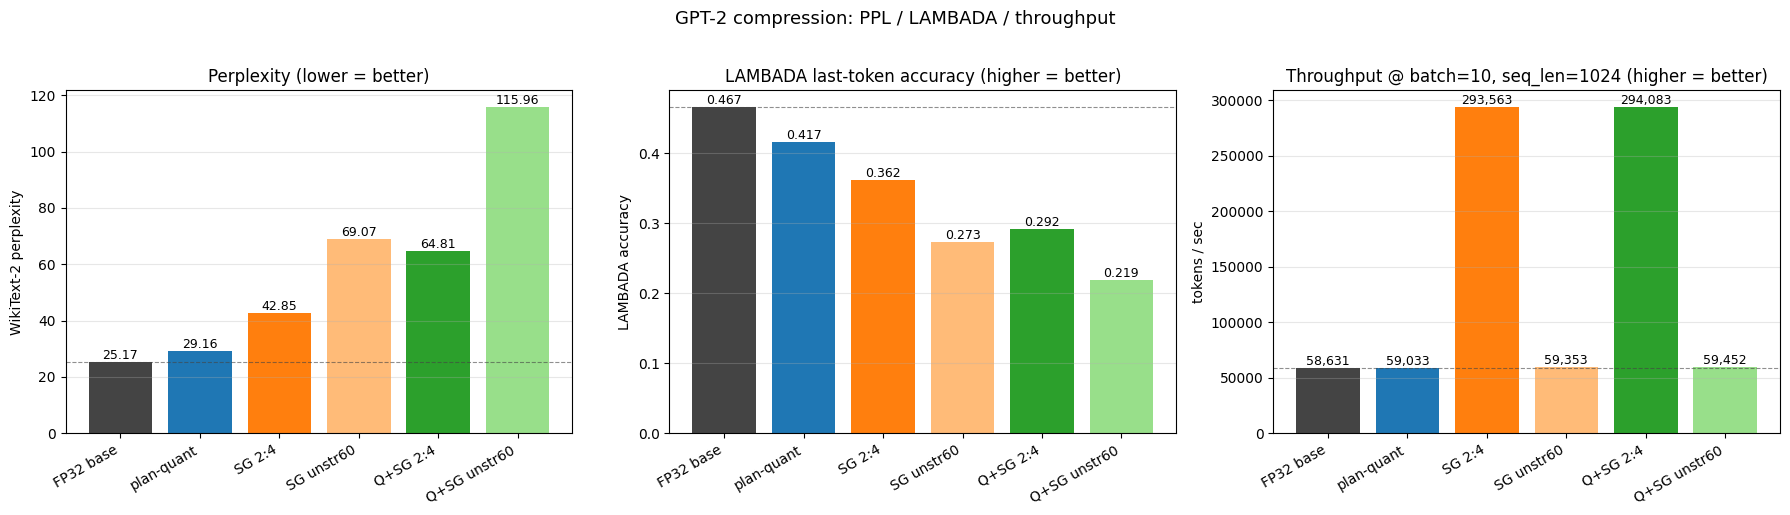

In [73]:
import matplotlib.pyplot as plt
import numpy as np

labels = [m[0] for m in BENCH_MODELS]
short_labels = [
    "FP32 base", "plan-quant",
    "SG 2:4", "SG unstr60",
    "Q+SG 2:4", "Q+SG unstr60",
]
ppl_vals = [ppl_results[l].perplexity for l in labels]
lam_vals = [lambada_results[l]["accuracy"] for l in labels]
tp_vals = [
    throughput_results[l]["tokens_per_sec"] if throughput_results.get(l) else 0.0
    for l in labels
]

# Colour code: baseline / plan-quant / orange-family (pruned from base) /
# green-family (pruned from plan-quant).
colors = ["#444444", "#1f77b4", "#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(labels))

# ── Perplexity (lower is better) ──
ax = axes[0]
bars = ax.bar(x, ppl_vals, color=colors)
ax.axhline(ppl_vals[0], color="#444444", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel("WikiText-2 perplexity")
ax.set_title("Perplexity (lower = better)")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, ppl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)

# ── LAMBADA accuracy (higher is better) ──
ax = axes[1]
bars = ax.bar(x, lam_vals, color=colors)
ax.axhline(lam_vals[0], color="#444444", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel("LAMBADA accuracy")
ax.set_title("LAMBADA last-token accuracy (higher = better)")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, lam_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

# ── Throughput (higher is better) ──
ax = axes[2]
bars = ax.bar(x, tp_vals, color=colors)
if tp_vals[0]:
    ax.axhline(tp_vals[0], color="#444444", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha="right")
ax.set_ylabel("tokens / sec")
ax.set_title(f"Throughput @ batch={BATCH}, seq_len={SEQ_LEN} (higher = better)")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, tp_vals):
    label = f"{v:,.0f}" if v else "OOM"
    ax.text(bar.get_x() + bar.get_width()/2, v, label,
            ha="center", va="bottom", fontsize=9)

plt.suptitle("GPT-2 compression: PPL / LAMBADA / throughput", fontsize=13, y=1.02)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "benchmark_charts.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"saved → {fig_path}")
plt.show()